In [1]:
import mikeio
import pywswat
import matplotlib.pyplot as plt

# INPUT FILE

In [2]:
fn_sample = r"D:\STKI\M21WFM\Examples\Ronne\Tri_irregular_3d_refined.mwfm - Result Files\area.dfsu"

In [3]:
ds = mikeio.read(fn_sample)

In [4]:
ds1 = ds.isel(element=slice(0, 50))

In [5]:
pywswat.spectrum_mem(
    ds1,
    "Surface elevation",
    u="Depth averaged U velocity",
    v="Depth averaged V velocity",
    method="newton",
    overlap=0.66667,
)

Computing MEM spectrum at spatial locations: 100%|██████████| 50/50 [00:17<00:00,  2.93it/s]


<pywswat.SpectraArray>  name: Energy density
dims: (time:1, element:50, direction:36, frequency:256)
frequency: 0.002 - 0.500 Hz  (256 bins)
direction: 0 - 350 deg  (36 bins)

In [5]:
ds_0d = ds.sel(x=479_800, y=6_105_400)

In [7]:
spec_0d = pywswat.spectrum_mem(
    ds_0d,
    "Surface elevation",
    u="Depth averaged U velocity",
    v="Depth averaged V velocity",
    method="newton",
    overlap=0.66667,
)

spec_0d

<pywswat.SpectraArray>  name: Energy density
dims: (time:1, direction:36, frequency:256)
frequency: 0.002 - 0.500 Hz  (256 bins)
direction: 0 - 350 deg  (36 bins)

In [10]:
spec_0d.to_params().to_dataframe(unit_in_name=True)

,Hm0 (meter),Tp (second),T01 (second),T02 (second),Tm10 (second),MWD (degree),PWD (degree),DSD (degree)
1990-01-01 12:17:30,1.827138,8.126984,7.921604,7.589897,9.030045,233.304812,230.0,0.217848


In [27]:
from pywswat.spectral import _mem_spectrum_point

In [31]:
import numpy as np

window_size = 512
overlap = 0.66667
method = "newton"
window = "hann"
g = 9.81
directions = np.arange(0, 360, 10, dtype=float)
directions = np.asarray(directions, dtype=float)
theta_rad = np.deg2rad(directions)

# eta_da = ds[elevation]
# u_da = ds[u]
# v_da = ds[v]

kwargs = dict(
    theta_rad=theta_rad,
    directions=directions,
    window_size=window_size,
    overlap=overlap,
    window=window,
    method=method,
    g=g,
)

In [32]:
_mem_spectrum_point(
    eta_da=ds_0d["Surface elevation"],
    u_da=ds_0d["Depth averaged U velocity"],
    v_da=ds_0d["Depth averaged V velocity"],
    **kwargs,
)

<pywswat.SpectraArray>  name: Energy density
dims: (time:1, direction:36, frequency:256)
frequency: 0.002 - 0.500 Hz  (256 bins)
direction: 0 - 350 deg  (36 bins)

In [33]:
eta_da = ds_0d["Surface elevation"]
u_da = ds_0d["Depth averaged U velocity"]
v_da = ds_0d["Depth averaged V velocity"]

In [37]:
from pywswat.spectral import (
    _dt_seconds,
    _center_time,
    _build_point_spectrum_da,
    _apply_mem,
)
from pywswat._fft import directional_fourier_coeffs


dt = _dt_seconds(eta_da)
eta = np.asarray(eta_da.values, dtype=float).ravel()
u = np.asarray(u_da.values, dtype=float).ravel()
v = np.asarray(v_da.values, dtype=float).ravel()

freqs, S_ee, a1, b1, a2, b2 = directional_fourier_coeffs(
    eta, u, v, dt, window_size, overlap, window, g=g
)

In [39]:
D = _apply_mem(theta_rad, a1, b1, a2, b2, method)  # (n_freqs, n_dirs)

In [40]:
S_2d_mikeio = (S_ee[:, None] * D).T  # (n_dirs, n_freqs)

t = _center_time(eta_da)
da = _build_point_spectrum_da(
    S_2d_mikeio, freqs, t, name="Energy density", directions=directions
)
# return SpectraArray(da)

In [36]:
freqs, S_ee, a1, b1, a2, b2 = directional_fourier_coeffs(
    eta, u, v, dt, window_size, overlap, window, g=g
)

D:\STKI\cloned_repos\pyWSWAT\src\pywswat\_plot.py:180: UserWarning: Log scale: values of z <= 0 have been masked
  cs = ax.contourf(


<PolarAxes: title={'center': 'Wave Spectrum'}>

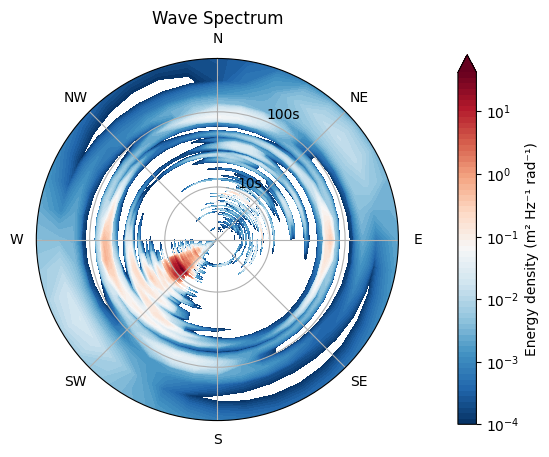

In [11]:
spec_0d.plot()

<Axes: title={'center': 'Wave Spectrum'}, xlabel='Frequency (Hz)', ylabel='Energy density (m² Hz⁻¹)'>

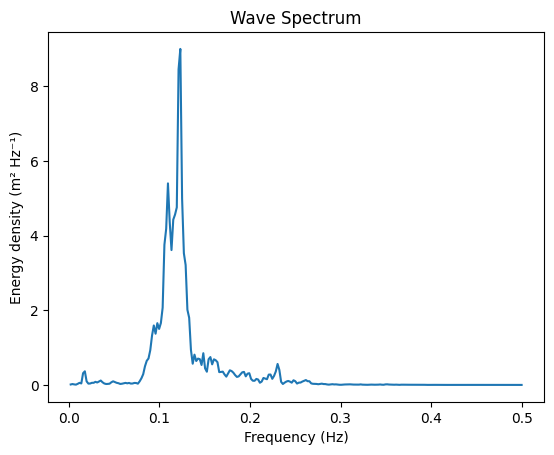

In [12]:
spec_0d.integrate_dir().plot()

In [106]:
spec_0d.to_params()["Hm0"]

<mikeio.DataArray>
name: Hm0
dims: (time:1)
time: 1990-01-01 12:17:30 (time-invariant)
geometry: GeometryUndefined()
values: [1.81799641]

# EXAMPLE 2

In [70]:
fn = r"D:\STKI\M21WFM\example0.mwfm - Result Files\2D_Surface_Elevation.dfsu"
ds = mikeio.read(fn)

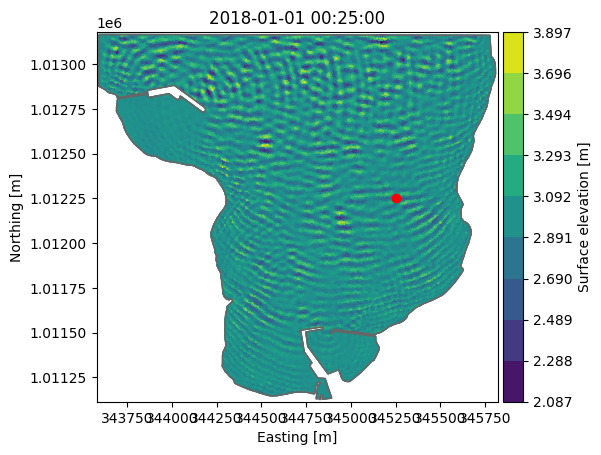

In [72]:
fig, ax = plt.subplots()
ds.isel(time=-1)["Surface elevation"].plot(ax=ax)
ax.scatter(345_250, 1_012_250, color="red", zorder=100)

In [81]:
ds_0d = ds.sel(x=345_250, y=1_012_250)

In [82]:
ds_0d

<mikeio.Dataset>
dims: (time:1501)
time: 2018-01-01 00:00:00 - 2018-01-01 00:25:00 (1501 records)
geometry: GeometryPoint2D(x=345249.0058318591, y=1012249.9168854747)
items:
  0:  Surface elevation <Surface Elevation> (meter)
  1:  U velocity <u velocity component> (meter per sec)
  2:  V velocity <v velocity component> (meter per sec)

In [86]:
spec_0d = pywswat.spectrum_mem(
    ds_0d, "Surface elevation", u="U velocity", v="V velocity", method="newton"
)

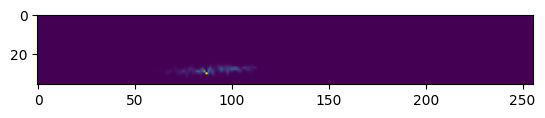

In [87]:
plt.imshow(spec_0d._da.values[0])

In [88]:
spec_0d.to_params().to_dataframe()

,Hm0,Tp,T01,T02,Tm10,MWD,PWD,DSD
2018-01-01 00:12:30,0.639666,5.818182,5.581426,5.531625,5.815919,283.77835,300.0,0.293704
